<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/EDA_dataset1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")

dk= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/ordenes_mecanica.csv")

display(dk.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CUSTOMER ID      508 non-null    int64 
 1   CITY             508 non-null    object
 2   STATE            508 non-null    object
 3   SERVICE HISTORY  508 non-null    object
 4   COMMON PROBLEM   508 non-null    object
 5   SOLUTION USED    508 non-null    object
 6   VEHICAL COMPANY  508 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.9+ KB


None

In [5]:
display(dk.head())

,CUSTOMER ID,CITY,STATE,SERVICE HISTORY,COMMON PROBLEM,SOLUTION USED,VEHICAL COMPANY
0,1,Ananthapuram,Andhra Pradesh,Oil Change; Brake Repair,Brake noise,Brake pad replacement,Maruti Suzuki
1,2,Ananthapuram,Andhra Pradesh,Engine Repair; Tire Rotation,Engine overheating,Radiator replacement,Hyundai
2,3,Ananthapuram,Andhra Pradesh,Bodywork; Paint Job,Dents and scratches,Body repair and repaint,Tata Motors
3,4,Ananthapuram,Andhra Pradesh,Oil Change; General Maintenance,Oil leak,Oil seal replacement,Mahindra & Mahindra
4,5,Ananthapuram,Andhra Pradesh,Tire Alignment; Engine Repair,Misaligned wheels,Wheel alignment,Honda


In [7]:
for col in dk.columns:
  numunico= dk[col].nunique()
  print(f"{col}: {numunico} valores distintos")

CUSTOMER ID: 500 valores distintos
CITY: 2 valores distintos
STATE: 2 valores distintos
SERVICE HISTORY: 126 valores distintos
COMMON PROBLEM: 71 valores distintos
SOLUTION USED: 61 valores distintos
VEHICAL COMPANY: 100 valores distintos


In [8]:
display(dk['COMMON PROBLEM'].value_counts().head(5))

,count
COMMON PROBLEM,
Cloudy headlights,49
Brake noise,41
Exhaust noise,32
Tire wear,31
Fluid leak,27


In [9]:
display(dk['VEHICAL COMPANY'].value_counts().head())

,count
VEHICAL COMPANY,
Hyundai,42
Ford,37
Hero MotoCorp,33
Tata Motors,31
Volkswagen,31


In [12]:
dk.isnull().count()

,0
CUSTOMER ID,508
CITY,508
STATE,508
SERVICE HISTORY,508
COMMON PROBLEM,508
SOLUTION USED,508
VEHICAL COMPANY,508


In [15]:
for col in dk.select_dtypes(include=['object']).columns:
    dk[col] = dk[col].astype(str).str.strip().str.upper()

print("Textos estandarizados correctamente.\n")

print("--- 2. Búsqueda de Nulos Ocultos ---")
valores_nulos_ocultos = ['', ' ', '-', 'N/A', 'NA', 'NONE', 'NULL', 'NAN', 'DESCONOCIDO']

dk.replace(valores_nulos_ocultos, np.nan, inplace=True)

# Ahora sí, le pedimos a Pandas que cuente la verdad
nulos_reales = dk.isnull().sum()
if nulos_reales.sum() > 0:
    print("¡Alerta! Se encontraron los siguientes nulos ocultos:")
    display(nulos_reales[nulos_reales > 0])
else:
    print("El dataset está verdaderamente limpio de nulos ocultos.")

print("\n--- 3. Revisión de Cardinalidad Post-Limpieza ---")
# Revisamos cuántas marcas o problemas únicos quedaron tras limpiar la sintaxis
for col in dk.drop(columns=['CUSTOMER ID'], errors='ignore').columns:
    print(f"{col}: {dk[col].nunique()} categorías únicas")

Textos estandarizados correctamente.

--- 2. Búsqueda de Nulos Ocultos ---
El dataset está verdaderamente limpio de nulos ocultos.

--- 3. Revisión de Cardinalidad Post-Limpieza ---
CITY: 1 categorías únicas
STATE: 1 categorías únicas
SERVICE HISTORY: 112 categorías únicas
COMMON PROBLEM: 52 categorías únicas
SOLUTION USED: 44 categorías únicas
VEHICAL COMPANY: 72 categorías únicas


In [16]:
dk= dk.drop(columns=['CITY', 'STATE'], errors='ignore')
print("Columnas 'CITY' y 'STATE' eliminadas (Varianza Cero).")

Columnas 'CITY' y 'STATE' eliminadas (Varianza Cero).


In [23]:
frecuencia_marcas= dk['VEHICAL COMPANY'].value_counts()
display(frecuencia_marcas.head(10))

,count
VEHICAL COMPANY,
HYUNDAI,45
FORD,40
HERO MOTOCORP,35
TATA MOTORS,34
VOLKSWAGEN,34
BAJAJ AUTO,31
KIA,29
TOYOTA,24
NISSAN,24


In [24]:
umbral= 10
marcas_populares= frecuencia_marcas[frecuencia_marcas > umbral].index

dk['VEHICAL COMPANY_AGRUPADA']= dk['VEHICAL COMPANY'].apply(
    lambda x: x if x in marcas_populares else 'OTRAS'
)

print(f"\nMarcas únicas ANTES de agrupar: {dk['VEHICAL COMPANY'].nunique()}")
print(f"Marcas únicas DESPUÉS de agrupar: {dk['VEHICAL COMPANY_AGRUPADA'].nunique()}")


Marcas únicas ANTES de agrupar: 72
Marcas únicas DESPUÉS de agrupar: 15


,count
COMMON PROBLEM,
CLOUDY HEADLIGHTS,49
BRAKE NOISE,45
EXHAUST NOISE,37
TIRE WEAR,34
FLUID LEAK,30
STEERING ISSUES,24
ENGINE OVERHEATING,22
BRAKE FLUID LEAK,19
MISALIGNED TIRES,19


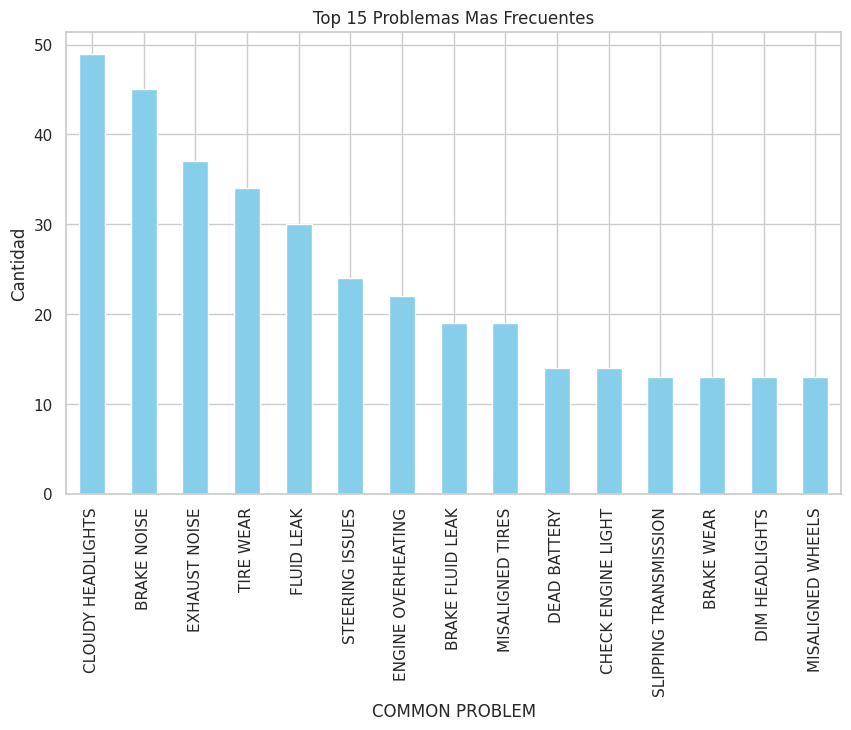

In [26]:
frecuencia_problemas= dk['COMMON PROBLEM'].value_counts()
display(frecuencia_problemas.head(20))

plt.figure(figsize=(10, 6))
frecuencia_problemas.head(15).plot(kind='bar', color='skyblue')
plt.title('Top 15 Problemas Mas Frecuentes')
plt.ylabel('Cantidad')
plt.show()

In [27]:
def categorizar_problema(problema):
  p= problema.lower()

  if 'freno' in p:
        return 'FRENOS'
  elif 'motor' in p or 'temperatura' in p or 'calentamiento' in p:
      return 'MOTOR'
  elif 'suspension' in p or 'amortiguador' in p:
       return 'SUSPENSION'
  elif 'electrico' in p or 'bateria' in p or 'luces' in p:
      return 'ELECTRICO'
  elif 'mantenimiento' in p or 'aceite' in p or 'filtro' in p:
      return 'MANTENIMIENTO'
  else:
      return 'OTROS'

In [29]:
dk['CATEGORIA_PROBLEMA']= dk['COMMON PROBLEM'].apply(categorizar_problema)
print(dk['CATEGORIA_PROBLEMA'].value_counts())

CATEGORIA_PROBLEMA
OTROS    508
Name: count, dtype: int64


In [31]:
dk_problem= pd.get_dummies(dk, columns=['CATEGORIA_PROBLEMA', 'VEHICAL COMPANY_AGRUPADA'])
print(dk_problem)

     CUSTOMER ID                          SERVICE HISTORY  \
0              1                 OIL CHANGE; BRAKE REPAIR   
1              2             ENGINE REPAIR; TIRE ROTATION   
2              3                      BODYWORK; PAINT JOB   
3              4          OIL CHANGE; GENERAL MAINTENANCE   
4              5            TIRE ALIGNMENT; ENGINE REPAIR   
..           ...                                      ...   
503          496  HEADLIGHT RESTORATION; SUSPENSION CHECK   
504          497    HEADLIGHT RESTORATION; TIRE ALIGNMENT   
505          498        HEADLIGHT RESTORATION; OIL CHANGE   
506          499       HEADLIGHT RESTORATION; BRAKE CHECK   
507          500     HEADLIGHT RESTORATION; TIRE ROTATION   

          COMMON PROBLEM            SOLUTION USED      VEHICAL COMPANY  \
0            BRAKE NOISE    BRAKE PAD REPLACEMENT        MARUTI SUZUKI   
1     ENGINE OVERHEATING     RADIATOR REPLACEMENT              HYUNDAI   
2    DENTS AND SCRATCHES  BODY REPAIR AND REP

/tmp/ipykernel_16991/1892644837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dk, y='CATEGORIA_PROBLEMA', order=dk['CATEGORIA_PROBLEMA'].value_counts().index, palette='viridis')


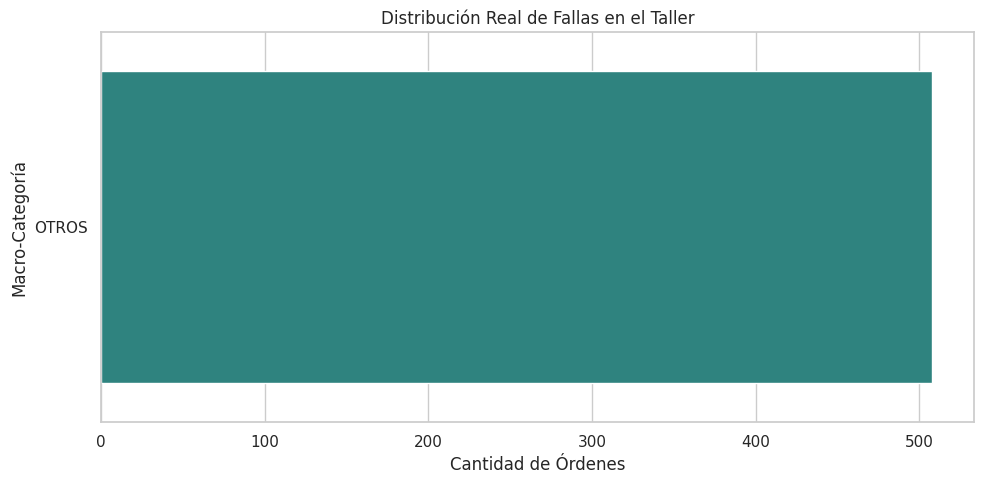

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=dk, y='CATEGORIA_PROBLEMA', order=dk['CATEGORIA_PROBLEMA'].value_counts().index, palette='viridis')
plt.title('Distribución Real de Fallas en el Taller')
plt.xlabel('Cantidad de Órdenes')
plt.ylabel('Macro-Categoría')
plt.tight_layout()
plt.show()

In [36]:
df_model = pd.get_dummies(dk, columns=['CATEGORIA_PROBLEMA', 'VEHICAL COMPANY_AGRUPADA'])